# Why does xarray need an *index*? (and when a **custom** one)

A coordinate is *just an array of labels*. So why doesn't xarray simply **scan that array** every time you call `.sel`? Why is there a whole separate `Index` object — and why would you ever write your *own*?

The one-line answer we'll build up to: **an index lets xarray exploit *structure* in your data to select from it ergonomically and efficiently.** A sorted 1‑D coordinate has structure (order); scattered points have structure (proximity); a computed grid has structure (a rule). Different structures call for different indexes.

We start with **data measured at points around a circle** and build up:

1. **A built-in index is enough** — `angle` is 1‑D and monotonic, so the default `PandasIndex` gives you ergonomics + alignment for free.
2. **Selecting by position** — even a full `(x, y)` query on the circle secretly collapses back to 1‑D (a circle *is* a 1‑D shape), so it *still* needs nothing fancy.
3. **When 1‑D truly fails** — a *noisy* ring is genuinely 2‑D, so we reach for the ready-made **`NDPointIndex`**.
4. **Build your own index** 📝 — when coordinates follow a *rule*, a tiny **`CoordinateTransform`** beats a generic index. We ramp up in three steps: a 1‑D **ruler** (sample → time), a 2‑D **affine grid**, then a nonlinear **fisheye lens**. *This is the exercise.*

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from xarray import Coordinates
from xarray.indexes import (
    CoordinateTransform,
    CoordinateTransformIndex,
    NDPointIndex,
    RangeIndex,
)

# 24 sensors placed evenly around a unit circle
n = 24
angle = np.arange(0, 360, 360 // n)          # degrees: 0, 15, 30, ... 345  (monotonic!)
theta = np.deg2rad(angle)
x = np.cos(theta)
y = np.sin(theta)

# the thing we measured at each sensor: a smooth temperature gradient
temperature = 20 + 10 * np.cos(theta)

# angle is the DIMENSION coordinate; x and y are extra (non-dimension) coordinates
da = xr.DataArray(
    temperature,
    dims="angle",
    coords={"angle": angle, "x": ("angle", x), "y": ("angle", y)},
    name="temperature",
)
da

<xarray.DataArray 'temperature' (angle: 24)> Size: 192B
array([30.        , 29.65925826, 28.66025404, 27.07106781, 25.        ,
       22.58819045, 20.        , 17.41180955, 15.        , 12.92893219,
       11.33974596, 10.34074174, 10.        , 10.34074174, 11.33974596,
       12.92893219, 15.        , 17.41180955, 20.        , 22.58819045,
       25.        , 27.07106781, 28.66025404, 29.65925826])
Coordinates:
  * angle    (angle) int64 192B 0 15 30 45 60 75 90 ... 270 285 300 315 330 345
    x        (angle) float64 192B 1.0 0.9659 0.866 ... 0.7071 0.866 0.9659
    y        (angle) float64 192B 0.0 0.2588 0.5 0.7071 ... -0.7071 -0.5 -0.2588

## First, just look at it

Each dot is a sensor on the circle, colored by its temperature.

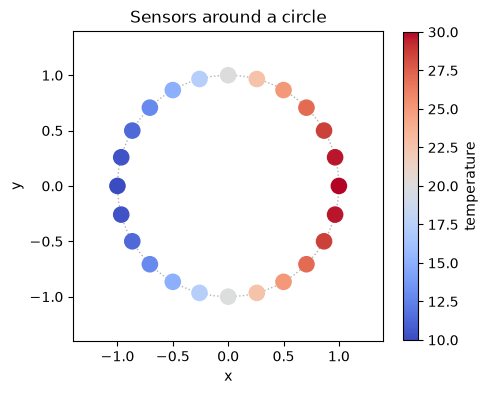

In [3]:
def draw_circle(ax, r=1, lim=1.4):
    circ = plt.Circle((0, 0), r, fill=False, ls=":", color="0.7")
    ax.add_patch(circ)
    ax.set_aspect("equal")
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel("x"); ax.set_ylabel("y")

fig, ax = plt.subplots(figsize=(5, 5))
draw_circle(ax)
sc = ax.scatter(da.x, da.y, c=da, cmap="coolwarm", s=120, zorder=3)
fig.colorbar(sc, ax=ax, label="temperature", shrink=0.8)
ax.set_title("Sensors around a circle")
plt.show()

## A coordinate is just an array

The `angle` coordinate is nothing but a plain array of numbers. Suppose you want *"the sensor nearest 95°."*

In [4]:
da["angle"]

<xarray.DataArray 'angle' (angle: 24)> Size: 192B
array([  0,  15,  30,  45,  60,  75,  90, 105, 120, 135, 150, 165, 180, 195,
       210, 225, 240, 255, 270, 285, 300, 315, 330, 345])
Coordinates:
  * angle    (angle) int64 192B 0 15 30 45 60 75 90 ... 270 285 300 315 330 345
    x        (angle) float64 192B 1.0 0.9659 0.866 ... 0.7071 0.866 0.9659
    y        (angle) float64 192B 0.0 0.2588 0.5 0.7071 ... -0.7071 -0.5 -0.2588

### The naive way: scan the array yourself

You *could* do the lookup by hand — compute the distance to every label and take the smallest:

In [5]:
target = 95
pos = np.argmin(np.abs(da["angle"].values - target))   # <- a full O(n) scan
print(f"nearest sensor to {target}° is at index {pos}, angle {da['angle'].values[pos]}°")
da.isel(angle=pos)

nearest sensor to 95° is at index 6, angle 90°


<xarray.DataArray 'temperature' ()> Size: 8B
array(20.)
Coordinates:
    angle    int64 8B 90
    x        float64 8B 6.123e-17
    y        float64 8B 1.0

That works — but notice it's all **manual plumbing**. You computed the distances yourself; you'd hand-write `nearest`; a **range** like *90°–180°* needs more code; and combining two datasets by label (**alignment**) is a project of its own. None of it *composes*.

An index turns all of that into readable, label-based one-liners. In this 1‑D case, that **ergonomics** — not speed — is the real reason to reach for it.

## Let the index do it

Because `angle` is a **dimension coordinate**, xarray automatically built a `PandasIndex` for it:

In [6]:
da.xindexes

Indexes:
    angle    PandasIndex

In [7]:
# nearest lookup — no manual argmin, and it uses the index (fast, O(log n) / O(1))
print("nearest 95°:")
print(da.sel(angle=95, method="nearest").item(), "°C")

# a label RANGE — impossible to express as "scan for equality"
arc = da.sel(angle=slice(90, 180))
print("\nsensors on the 90°–180° arc:", arc["angle"].values)

nearest 95°:
20.0 °C

sensors on the 90°–180° arc: [ 90 105 120 135 150 165 180]


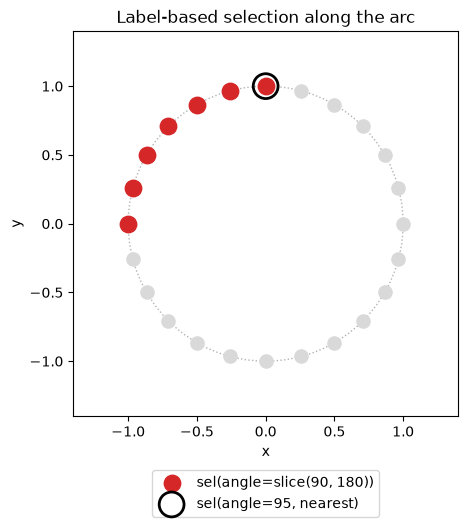

In [8]:
# show what .sel picked out, back on the circle
fig, ax = plt.subplots(figsize=(5, 5))
draw_circle(ax)
ax.scatter(da.x, da.y, c="0.85", s=90, zorder=2)                       # all sensors, greyed
ax.scatter(arc.x, arc.y, c="tab:red", s=140, zorder=3, label="sel(angle=slice(90, 180))")
near = da.sel(angle=95, method="nearest")
ax.scatter(near.x, near.y, edgecolor="k", facecolor="none", s=320, lw=2,
           zorder=4, label="sel(angle=95, nearest)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.28))
ax.set_title("Label-based selection along the arc")
plt.show()

## Alignment: the other everyday win

The second reason 1‑D indexes matter day to day is **alignment**. Suppose a *second* instrument sampled the circle at a **coarser** set of angles. Just add the two arrays — xarray matches them by their `angle` **labels** (an index join), not by position:

In [9]:
coarse_angle = np.arange(0, 360, 45)      # every 45° only
humidity = xr.DataArray(
    50 + 5 * np.sin(np.deg2rad(coarse_angle)),
    dims="angle", coords={"angle": coarse_angle}, name="humidity",
)

combined = da + humidity                   # index join on `angle`
print("kept only the shared angles:", combined["angle"].values)
combined

kept only the shared angles: [  0  45  90 135 180 225 270 315]


<xarray.DataArray (angle: 8)> Size: 64B
array([80.        , 80.60660172, 75.        , 66.46446609, 60.        ,
       59.39339828, 65.        , 73.53553391])
Coordinates:
  * angle    (angle) int64 64B 0 45 90 135 180 225 270 315
    x        (angle) float64 64B 1.0 0.7071 6.123e-17 ... -1.837e-16 0.7071
    y        (angle) float64 64B 0.0 0.7071 1.0 0.7071 ... -0.7071 -1.0 -0.7071

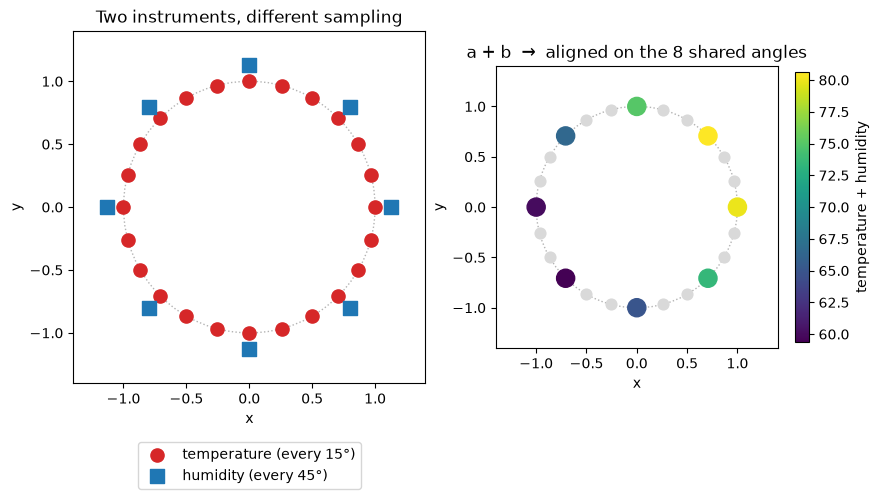

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
for ax in (ax1, ax2):
    draw_circle(ax)

# left: the two samplings. `temperature` already carries x/y coords; humidity has only angle
hx, hy = np.cos(np.deg2rad(coarse_angle)), np.sin(np.deg2rad(coarse_angle))
ax1.scatter(da.x, da.y, s=90, c="tab:red", label="temperature (every 15°)", zorder=3)
ax1.scatter(hx * 1.13, hy * 1.13, s=90, marker="s", c="tab:blue",
            label="humidity (every 45°)", zorder=3)
ax1.set_title("Two instruments, different sampling")
ax1.legend(loc="lower center", bbox_to_anchor=(0.5, -0.32))

# right: a + b kept only the shared angles — and its x/y coords came along for free
ax2.scatter(da.x, da.y, s=60, c="0.85", zorder=2)
sc = ax2.scatter(combined.x, combined.y, s=170, c=combined, cmap="viridis", zorder=3)
fig.colorbar(sc, ax=ax2, shrink=0.7, label="temperature + humidity")
ax2.set_title("a + b  →  aligned on the 8 shared angles")
plt.show()

### Recap: the 1‑D index

On a **1‑D** coordinate, xarray's default [`PandasIndex`](https://docs.xarray.dev/en/stable/generated/xarray.indexes.PandasIndex.html) gives you:

- **ergonomics** — `nearest`, `tolerance`, and label `slice` as clean one-liners
- **alignment** — automatic label joins in `+`, `concat`, `merge`
- **efficient lookups** — a *hash table* for exact matches, plus *binary search* over the sorted labels for ranges and `nearest` (which is exactly why those need a **monotonic** index)

You never asked for an index — `angle` being a *dimension coordinate* created one automatically.

The idea to carry forward: an index is a **precomputed lookup structure**, and the richer the *structure* in your data, the more a well-matched index can exploit. A sorted 1‑D coordinate only has *order* (→ binary search). Real data often has richer structure — proximity, or a generating rule — and that's where a single 1‑D index runs out.

## The same 1‑D index, in the wild: a video's time axis

The circle's `angle` was a tidy demo. But the built-in [`PandasIndex`](https://docs.xarray.dev/en/stable/generated/xarray.indexes.PandasIndex.html) is **everywhere** in real data — often where you don't think of it as an "index" at all. A video is a nice example: it's just a stack of frames, and each frame happens at a **time**.

We'll open a short clip with a tiny xarray backend that reads image formats (`ocean.gif`), so the whole video arrives as an ordinary `Dataset`. The key thing to watch: the backend gives the `time` axis a plain `PandasIndex` — the *same* index the circle used — because **frames map 1‑to‑1 to timestamps**. That 1‑D, monotonic structure is exactly what `PandasIndex` is for, so `.sel` by timestamp just works. **No custom index required.**

In [11]:
# A little xarray backend (from the "Backends" tutorial) that reads image formats via imageio.
# It turns a gif/mp4 into a Dataset with dims (time, height, width, color).
import sys

sys.path.insert(0, "../../advanced/backends")
from imageio_ import ImageIOBackend

# .load() pulls the whole (small) clip into memory up front
ocean = xr.open_dataset("../../advanced/backends/ocean.gif", engine=ImageIOBackend).load()
ocean

<xarray.Dataset> Size: 7MB
Dimensions:  (time: 18, height: 267, width: 498, color: 3)
Coordinates:
  * time     (time) timedelta64[ms] 144B 00:00:00 ... 00:00:01.700000
  * color    (color) <U5 60B 'red' 'green' 'blue'
Dimensions without coordinates: height, width
Data variables:
    data     (time, height, width, color) uint8 7MB 236 230 214 ... 206 189 176

Look at the coordinates: `time` is a `timedelta64` running from 0 to 1.7 s (this clip is 18 frames at 100 ms each), and — just like `angle` on the circle — xarray built a **`PandasIndex`** for it automatically. (`color` is a dimension coordinate too, so it gets one as well; `time` is the axis we care about here.)

In [12]:
ocean.xindexes

Indexes:
    time     PandasIndex
    color    PandasIndex

So "give me the frame nearest 0.8 seconds" is a one-liner — label-based selection on the `time` index, exactly like `.sel(angle=95, method="nearest")` earlier. The index does the lookup; we never touch a frame number.

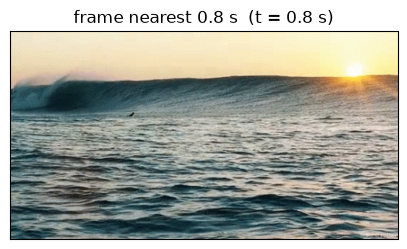

In [13]:
import matplotlib.pyplot as plt

# select by timestamp (not by frame number!) — the PandasIndex finds the nearest frame
frame = ocean.sel(time="0.8s", method="nearest")
seconds = frame.time.values / np.timedelta64(1, "s")

fig, ax = plt.subplots(figsize=(5, 3))
ax.imshow(frame["data"].values)
ax.set(title=f"frame nearest 0.8 s  (t = {seconds:g} s)", xticks=[], yticks=[])
plt.show()

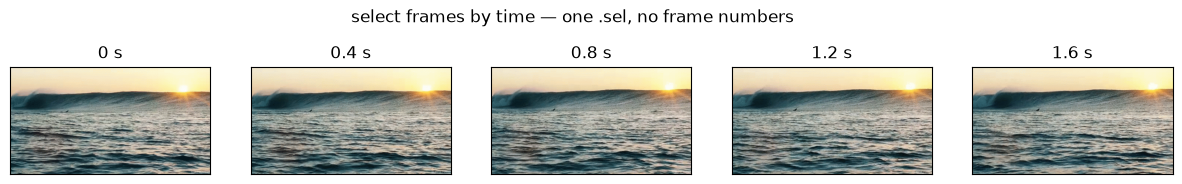

In [14]:
# 📝 Play with it: change these timestamps (in seconds) and re-run — .sel picks the nearest frame each time
times = ["0s", "0.4s", "0.8s", "1.2s", "1.6s"]

montage = ocean["data"].sel(time=times, method="nearest")
fig, axes = plt.subplots(1, len(times), figsize=(3 * len(times), 2))
for ax, t in zip(axes, montage.time.values):
    ax.imshow(montage.sel(time=t).values)
    ax.set(title=f"{t / np.timedelta64(1, 's'):g} s", xticks=[], yticks=[])
fig.suptitle("select frames by time — one .sel, no frame numbers", y=1.05)
plt.show()

```{admonition} Don't reach for a custom index here
:class: warning
It's tempting to think "my data has a fancy time axis, I need a custom index." You don't. Because **frames map 1‑to‑1 to timestamps** — one monotonic, 1‑D coordinate — the built-in `PandasIndex` already does everything: `nearest`, slices (`.sel(time=slice("0.5s", "1.5s"))`), and alignment against another clip. A custom index earns its keep only when your coordinates *can't* be expressed as a 1‑D array. We'll build up to exactly those cases.
```

The through-line for the rest of this notebook: **the richer the structure you can name, the more a well-matched index exploits it — and you only reach for something beyond `PandasIndex` when no simpler index fits.** Next we'll see two ways that happens with built-in indexes: when the 1‑D axis is *too big to store* (`RangeIndex`), and when selection is genuinely *2‑D* (`NDPointIndex`).

## When the 1‑D axis is too big to store: `RangeIndex`

Our ocean clip had 18 timestamps — nothing to worry about. But a *regular* 1‑D axis can get enormous. A 60 fps hour of video is ~216 000 frames; a connectomics electron-microscopy volume sampled every 4 nm can run to **billions** of planes. Materialized as `float64` labels, two billion of them is **~16 GB** for that *one coordinate* — before you've touched a single voxel.

Here's the thing: those labels are perfectly regular, `start + i·step`. You don't need to *store* them, you need to be able to *generate* any one on demand. That's exactly what xarray's built-in [`RangeIndex`](https://docs.xarray.dev/en/stable/generated/xarray.indexes.RangeIndex.html) does — it keeps three numbers (`start`, `stop`, `step`) and conjures labels lazily. Still built-in, still 1‑D, still **not** a custom index — just a smarter representation of the same kind of coordinate.

In [15]:
# a whole-brain EM stack: 2 billion z-planes at 4 nm spacing
n_z = 2_000_000_000
z = Coordinates.from_xindex(RangeIndex.arange(0.0, n_z * 4.0, 4.0, dim="z"))["z"]

print(f"{n_z:,} regularly-spaced labels — stored as 3 numbers, not "
      f"{n_z * 8 / 1e9:.0f} GB of array")
print("the coordinate is lazy:", type(z.variable._data).__name__)

# select by physical position (nm); only the requested points are ever computed
depth_nm = xr.DataArray([1e6, 5e6], dims="probe")     # 1 mm and 5 mm deep
print("nearest plane to each depth (nm):",
      z.sel(z=depth_nm, method="nearest").values)

2,000,000,000 regularly-spaced labels — stored as 3 numbers, not 16 GB of array
the coordinate is lazy: CoordinateTransformIndexingAdapter
nearest plane to each depth (nm): [1000000. 5000000.]


Two things to notice. The labels never materialized — `z` is backed by a `CoordinateTransformIndexingAdapter`, generated on demand (we'll meet that same machinery again when we write our *own* index). And `RangeIndex.sel` matches with `method="nearest"`: it's a continuous ruler, not a hash table.

So far every index has been **1‑D** — circle `angle`, video `time`, EM `z`. Selection always collapsed to a position along a single ordered axis. That covers a huge amount of real data. But what happens when the question is genuinely **two-dimensional** — "the sensor nearest this `(x, y)` point" — and no single axis captures it?

## Selecting by *position* (x, y)

Everything so far used `angle`. What if we select by the **(x, y) position** instead — "the sensor nearest this point on the plane"?

First, a single coordinate isn't enough: `x` is not monotonic around the circle, so `x = 0.5` matches **two** sensors (60° and 300°). A lone `x` value doesn't name a *point*, so a 1‑D index on `x` alone can't work:

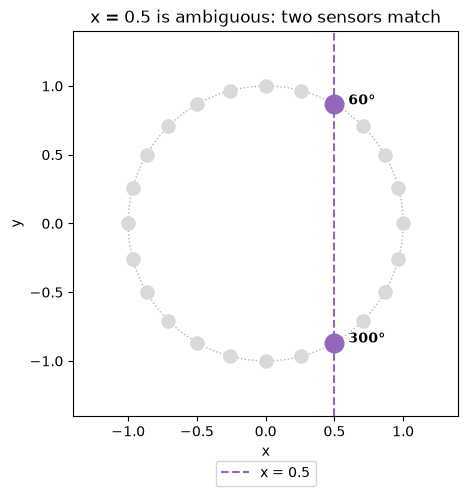

In [16]:
fig, ax = plt.subplots(figsize=(5, 5))
draw_circle(ax)
ax.scatter(da.x, da.y, c="0.85", s=90, zorder=2)
ax.axvline(0.5, color="tab:purple", ls="--", label="x = 0.5")
hits = da.where(np.abs(da.x - 0.5) < 0.02, drop=True)
ax.scatter(hits.x, hits.y, c="tab:purple", s=180, zorder=3)
for a in hits["angle"].values:
    p = da.sel(angle=a)
    ax.annotate(f"{a}°", (float(p.x), float(p.y)), textcoords="offset points",
                xytext=(10, 0), fontweight="bold")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.2))
ax.set_title("x = 0.5 is ambiguous: two sensors match")
plt.show()

### ...but on the circle, a full `(x, y)` query is *still* 1‑D

Giving *both* `x` and `y` removes the ambiguity. But here's the twist that decides whether we even need a 2‑D index: **the nearest sensor to *any* point in the plane is simply the one in its direction from the centre.** Writing $P$ for the query, the distance to a sensor at angle $\theta$ is

$$d^2 = |P|^2 + R^2 - 2R\,|P|\cos(\varphi - \theta), \qquad \varphi = \operatorname{atan2}(y, x)$$

and only the $\cos(\varphi - \theta)$ term chooses the winner — minimised by the sensor whose **angle** is closest to $\varphi$, *no matter how far $P$ is from the circle*. So `(x, y)` selection collapses straight back to a 1‑D angle lookup:

In [17]:
rng = np.random.default_rng(0)
Q = rng.uniform(-1.6, 1.6, (3000, 2))              # query points scattered all over the plane
cx, cy = da.x.values, da.y.values

# true nearest by full 2-D distance ...
by_2d = ((Q[:, 0, None] - cx) ** 2 + (Q[:, 1, None] - cy) ** 2).argmin(1)
# ... vs nearest by ANGLE alone (a 1-D lookup)
phi = np.arctan2(Q[:, 1], Q[:, 0]) % (2 * np.pi)
by_angle = np.rint(phi / (2 * np.pi) * n).astype(int) % n

print(f"1-D angle == full 2-D nearest for {(by_2d == by_angle).mean() * 100:.0f}% of queries")
print("=> on a clean circle, even (x, y) selection needs no 2-D index")

1-D angle == full 2-D nearest for 100% of queries
=> on a clean circle, even (x, y) selection needs no 2-D index


## When 1‑D really isn't enough: a *noisy* ring

That shortcut worked only because every sensor shared the same radius $R$, so $R$ cancelled. Real measurements aren't so tidy. Jitter each radius and the points leave the 1‑D circle — now a sensor at a slightly different angle but a *closer radius* can be the true nearest, and the angle shortcut picks the wrong one:

In [18]:
m = 120
th_ring = np.linspace(0, 2 * np.pi, m, endpoint=False)
radius = 1 + np.random.default_rng(1).normal(0, 0.15, m)     # radius jitter -> off the circle
rx, ry = radius * np.cos(th_ring), radius * np.sin(th_ring)
ring = xr.DataArray(20 + 5 * np.sin(2 * th_ring), dims="point",
                    coords={"x": ("point", rx), "y": ("point", ry)}, name="temperature")

Q = np.random.default_rng(0).uniform(-1.4, 1.4, (3000, 2))
by_2d = ((Q[:, 0, None] - rx) ** 2 + (Q[:, 1, None] - ry) ** 2).argmin(1)
by_angle = np.rint((np.arctan2(Q[:, 1], Q[:, 0]) % (2 * np.pi)) / (2 * np.pi) * m).astype(int) % m
print(f"1-D angle == 2-D nearest for only {(by_2d == by_angle).mean() * 100:.0f}% of queries now "
      f"(was 100% on the clean circle)")

1-D angle == 2-D nearest for only 24% of queries now (was 100% on the clean circle)


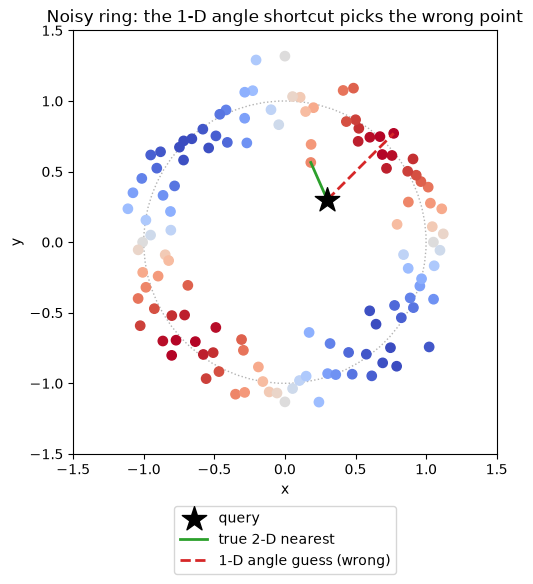

In [20]:
# a query point where the 1-D angle guess is WRONG: the nearest point by *angle*
# sits farther out radially than a neighbor at a slightly different angle
qp = np.array([0.3, 0.3])
i2d = int(((rx - qp[0]) ** 2 + (ry - qp[1]) ** 2).argmin())   # true nearest (full 2-D distance)
iang = int(np.rint((np.arctan2(qp[1], qp[0]) % (2 * np.pi)) / (2 * np.pi) * m) % m)   # 1-D angle guess

fig, ax = plt.subplots(figsize=(5.5, 5.5))
draw_circle(ax, lim=1.5)
ax.scatter(rx, ry, c=ring, cmap="coolwarm", s=45, zorder=2)
ax.scatter(*qp, marker="*", s=340, c="k", zorder=5, label="query")
ax.plot([qp[0], rx[i2d]], [qp[1], ry[i2d]], "-", c="tab:green", lw=2, label="true 2-D nearest")
ax.plot([qp[0], rx[iang]], [qp[1], ry[iang]], "--", c="tab:red", lw=2, label="1-D angle guess (wrong)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.3))
ax.set_title("Noisy ring: the 1-D angle shortcut picks the wrong point")
plt.show()

## A ready-made 2‑D index: `NDPointIndex`

The data is now genuinely 2‑D, so we need an index built for that — but we don't have to write it. Xarray ships [`NDPointIndex`](https://docs.xarray.dev/en/stable/generated/xarray.indexes.NDPointIndex.html), which puts a [KD‑tree](https://en.wikipedia.org/wiki/K-d_tree) over `x` **and** `y` together. Attach it with `set_xindex`, and `.sel` on a whole point just works.

The first query point below is the very `(0.3, 0.3)` that fooled the angle shortcut above — watch `NDPointIndex` recover the correct nearest point (the green line from the last plot).

> 💡 Before writing a custom index, browse the **[Xarray Indexes Gallery](https://xarray-indexes.readthedocs.io/)** ([source](https://github.com/xarray-contrib/xarray-indexes)) — geospatial, staggered-grid, out-of-core and other ready-made indexes may already fit your data.

In [21]:
ring_idx = ring.set_xindex(["x", "y"], NDPointIndex)     # one index over BOTH x and y

qx = xr.DataArray([qp[0], -0.8, 0.6], dims="q")
qy = xr.DataArray([qp[1], 0.2, -0.9], dims="q")
picked = ring_idx.sel(x=qx, y=qy, method="nearest")      # true 2-D nearest
print("nearest points:", [tuple(np.round(p, 2)) for p in zip(picked.x.values, picked.y.values)])
ring_idx.xindexes

nearest points: [(np.float64(0.18), np.float64(0.56)), (np.float64(-0.81), np.float64(0.22)), (np.float64(0.62), np.float64(-0.95))]


Indexes:
  ┌ x        NDPointIndex (ScipyKDTreeAdapter)
  └ y

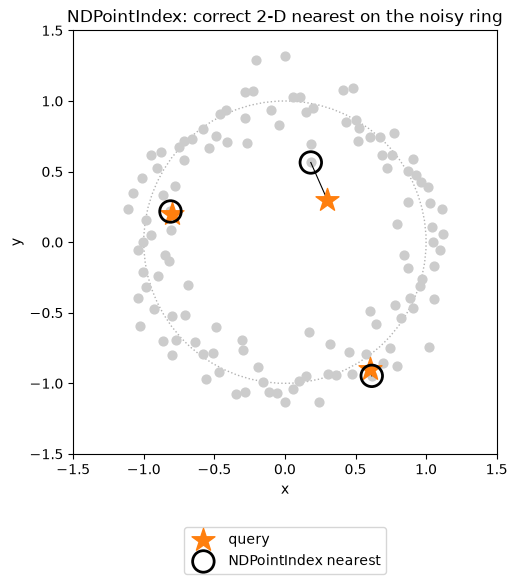

In [22]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
draw_circle(ax, lim=1.5)
ax.scatter(rx, ry, c="0.8", s=40, zorder=2)
ax.scatter(qx, qy, marker="*", s=300, c="tab:orange", zorder=5, label="query")
ax.scatter(picked.x, picked.y, edgecolor="k", facecolor="none", s=240, lw=2,
           zorder=6, label="NDPointIndex nearest")
for i in range(len(qx)):
    ax.plot([float(qx[i]), float(picked.x[i])], [float(qy[i]), float(picked.y[i])],
            "k-", lw=0.8, zorder=3)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.3))
ax.set_title("NDPointIndex: correct 2-D nearest on the noisy ring")
plt.show()

## Build your own index — start with the simplest rule (1-D)

Before the 2-D lens, here's the whole `CoordinateTransform` idea in its smallest form. A signal is sampled at a fixed **rate**: we store the **sample index**, but want to select (and plot) by **time**. The rule is `time = index / rate` — so store the *rule*, not a time array. A transform is three methods:

- `forward` — index → time
- `reverse` — time → index
- `equals` — are two transforms the same? (used for alignment)

::::{admonition} Exercise — implement the ruler
:class: tip

Fill in `forward` and `reverse` so the transform maps sample index ↔ time (`time = index / rate`). `equals` is given.

```python
class RulerTransform(CoordinateTransform):
    def __init__(self, n, rate):
        super().__init__(("time",), {"sample": n})
        self.n, self.rate = n, rate

    def forward(self, dim_positions):     # index -> time
        ...

    def reverse(self, coord_labels):      # time -> index
        ...

    def equals(self, other, exclude=None):
        return isinstance(other, RulerTransform) and (self.n, self.rate) == (other.n, other.rate)
```

:::{admonition} Solution
:class: dropdown
```python
    def forward(self, dim_positions):     # index -> time
        return {"time": dim_positions["sample"] / self.rate}

    def reverse(self, coord_labels):      # time -> index
        return {"sample": coord_labels["time"] * self.rate}
```
:::
::::

In [44]:
class RulerTransform(CoordinateTransform):
    """1-D: sample index  <->  time (seconds).   time = index / rate"""

    def __init__(self, n, rate):
        super().__init__(("time",), {"sample": n})
        self.n, self.rate = n, rate

    def forward(self, dim_positions):        # index -> time
        return {"time": dim_positions["sample"] / self.rate}

    def reverse(self, coord_labels):         # time -> index
        return {"sample": coord_labels["time"] * self.rate}

    def equals(self, other, exclude=None):
        return isinstance(other, RulerTransform) and (self.n, self.rate) == (other.n, other.rate)

In [45]:
# attach the transform as an index; 'time' becomes a lazy coordinate, generated by the rule
rate = 1000  # Hz
signal = xr.DataArray(np.sin(2 * np.pi * 50 * np.arange(500) / rate), dims="sample",
                      coords=Coordinates.from_xindex(CoordinateTransformIndex(RulerTransform(500, rate))),
                      name="amplitude")
signal

<xarray.DataArray 'amplitude' (sample: 500)> Size: 4kB
array([ 0.00000000e+00,  3.09016994e-01,  5.87785252e-01,  8.09016994e-01,
        9.51056516e-01,  1.00000000e+00,  9.51056516e-01,  8.09016994e-01,
        5.87785252e-01,  3.09016994e-01, -3.21624530e-16, -3.09016994e-01,
       -5.87785252e-01, -8.09016994e-01, -9.51056516e-01, -1.00000000e+00,
       -9.51056516e-01, -8.09016994e-01, -5.87785252e-01, -3.09016994e-01,
        6.43249060e-16,  3.09016994e-01,  5.87785252e-01,  8.09016994e-01,
        9.51056516e-01,  1.00000000e+00,  9.51056516e-01,  8.09016994e-01,
        5.87785252e-01,  3.09016994e-01,  3.67394040e-16, -3.09016994e-01,
       -5.87785252e-01, -8.09016994e-01, -9.51056516e-01, -1.00000000e+00,
       -9.51056516e-01, -8.09016994e-01, -5.87785252e-01, -3.09016994e-01,
        1.28649812e-15,  3.09016994e-01,  5.87785252e-01,  8.09016994e-01,
        9.51056516e-01,  1.00000000e+00,  9.51056516e-01,  8.09016994e-01,
        5.87785252e-01,  3.09016994e-01,  6.12323400e-16, -3.09016994e-01,
       -5.87785252e-01, -8.09016994e-01, -9.51056516e-01, -1.00000000e+00,
       -9.51056516e-01, -8.09016994e-01, -5.87785252e-01, -3.09016994e-01,
       -7.34788079e-16,  3.09016994e-01,  5.87785252e-01,  8.09016994e-01,
        9.51056516e-01,  1.00000000e+00,  9.51056516e-01,  8.09016994e-01,
        5.87785252e-01,  3.09016994e-01, -2.69546092e-15, -3.09016994e-01,
       -5.87785252e-01, -8.09016994e-01, -9.51056516e-01, -1.00000000e+00,
       -9.51056516e-01, -8.09016994e-01, -5.87785252e-01, -3.09016994e-01,
...
        1.96191080e-15,  3.09016994e-01,  5.87785252e-01,  8.09016994e-01,
        9.51056516e-01,  1.00000000e+00,  9.51056516e-01,  8.09016994e-01,
        5.87785252e-01,  3.09016994e-01, -1.96030145e-14, -3.09016994e-01,
       -5.87785252e-01, -8.09016994e-01, -9.51056516e-01, -1.00000000e+00,
       -9.51056516e-01, -8.09016994e-01, -5.87785252e-01, -3.09016994e-01,
        8.82240880e-15,  3.09016994e-01,  5.87785252e-01,  8.09016994e-01,
        9.51056516e-01,  1.00000000e+00,  9.51056516e-01,  8.09016994e-01,
        5.87785252e-01,  3.09016994e-01,  1.95819692e-15, -3.09016994e-01,
       -5.87785252e-01, -8.09016994e-01, -9.51056516e-01, -1.00000000e+00,
       -9.51056516e-01, -8.09016994e-01, -5.87785252e-01, -3.09016994e-01,
       -1.27388026e-14,  3.09016994e-01,  5.87785252e-01,  8.09016994e-01,
        9.51056516e-01,  1.00000000e+00,  9.51056516e-01,  8.09016994e-01,
        5.87785252e-01,  3.09016994e-01, -4.90230108e-15, -3.09016994e-01,
       -5.87785252e-01, -8.09016994e-01, -9.51056516e-01, -1.00000000e+00,
       -9.51056516e-01, -8.09016994e-01, -5.87785252e-01, -3.09016994e-01,
       -5.87830464e-15,  3.09016994e-01,  5.87785252e-01,  8.09016994e-01,
        9.51056516e-01,  1.00000000e+00,  9.51056516e-01,  8.09016994e-01,
        5.87785252e-01,  3.09016994e-01,  1.66589104e-14, -3.09016994e-01,
       -5.87785252e-01, -8.09016994e-01, -9.51056516e-01, -1.00000000e+00,
       -9.51056516e-01, -8.09016994e-01, -5.87785252e-01, -3.09016994e-01])
Coordinates:
  * time     (sample) float64 4kB 0.0 0.001 0.002 0.003 ... 0.497 0.498 0.499
Dimensions without coordinates: sample
Indexes:
    time     CoordinateTransformIndex

In [46]:
# select by time (seconds) in one call, though only the rule (n, rate) is stored
signal.sel(time=xr.DataArray([0.05, 0.10, 0.123], dims="t"), method="nearest")

<xarray.DataArray 'amplitude' (t: 3)> Size: 24B
array([ 6.12323400e-16, -1.22464680e-15,  8.09016994e-01])
Coordinates:
    time     (t) float64 24B 0.05 0.1 0.123
Dimensions without coordinates: t

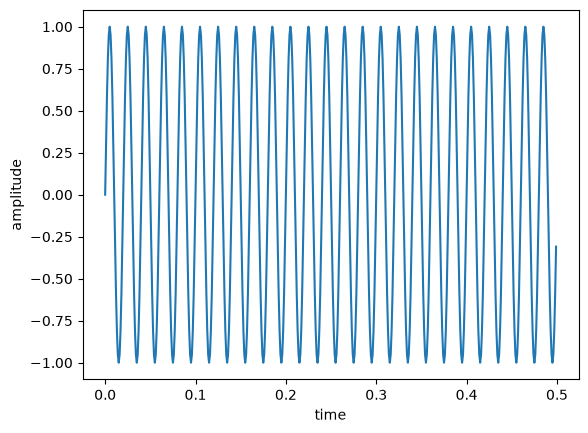

In [47]:
signal.plot(x="time")   # the x-axis is the 'time' coordinate, generated on demand by the rule
plt.show()

### You just built a DIY `RangeIndex`

A 1‑D coordinate generated from a rule (`start` + `i·step`), never stored — that's *exactly* what xarray's built‑in [`RangeIndex`](https://docs.xarray.dev/en/stable/generated/xarray.indexes.RangeIndex.html) does, the one we met earlier on the billion‑plane EM stack. Same machinery under the hood (`CoordinateTransformIndex` + a lazy adapter), just packaged and battle‑tested. **So in practice, reach for `RangeIndex` for a regular 1‑D axis** — you now know what's inside it. Writing your own transform earns its keep when the rule is something xarray *doesn't* already ship — which is where a 2‑D grid comes in.

## Step up to 2-D: a regular grid

The ruler was 1-D. Real spatial data is 2-D — and `NDPointIndex` would treat it as an unstructured cloud and build a tree. But a **regular grid** has structure a tree throws away: every cell's world position comes from an affine rule

$$x = x_0 + i\,\Delta x, \qquad y = y_0 + j\,\Delta y$$

so you needn't *store* `x` / `y`, and you needn't build a tree — selection just **inverts the arithmetic**. Same three methods as the ruler, now with two dimensions:

- `forward` — grid indices `(i, j)` → world `(x, y)`
- `reverse` — world `(x, y)` → grid indices
- `equals` — are two transforms the same? (used for alignment)

::::{admonition} Exercise — build the 2-D affine grid
:class: tip

Now the real thing. Implement `forward` and `reverse` for the affine rule above: integer grid indices (`"xi"` = i, `"yj"` = j) ↔ world `(x, y)`. `reverse` is just the inverse arithmetic — fractional indices are fine, xarray rounds for `nearest`. `equals` is given.

```python
class AffineGridTransform(CoordinateTransform):
    def __init__(self, x0, y0, dx, dy, nx, ny):
        super().__init__(("x", "y"), {"yj": ny, "xi": nx})
        self.x0, self.y0, self.dx, self.dy = x0, y0, dx, dy

    def forward(self, dim_positions):     # (i, j) -> (x, y)
        ...

    def reverse(self, coord_labels):      # (x, y) -> (i, j)
        ...

    def equals(self, other, exclude=None):
        return (isinstance(other, AffineGridTransform)
                and (self.x0, self.y0, self.dx, self.dy)
                    == (other.x0, other.y0, other.dx, other.dy))
```

:::{admonition} Solution
:class: dropdown
```python
    def forward(self, dim_positions):     # (i, j) -> (x, y)
        return {"x": self.x0 + dim_positions["xi"] * self.dx,
                "y": self.y0 + dim_positions["yj"] * self.dy}

    def reverse(self, coord_labels):      # (x, y) -> (i, j)
        return {"xi": (coord_labels["x"] - self.x0) / self.dx,
                "yj": (coord_labels["y"] - self.y0) / self.dy}
```
:::
::::

In [48]:
class AffineGridTransform(CoordinateTransform):
    """Regular grid: indices (i along 'xi', j along 'yj')  <->  world (x, y)."""

    def __init__(self, x0, y0, dx, dy, nx, ny):
        super().__init__(("x", "y"), {"yj": ny, "xi": nx})
        self.x0, self.y0, self.dx, self.dy = x0, y0, dx, dy

    def forward(self, dim_positions):      # grid -> world:  x = x0 + i*dx,  y = y0 + j*dy
        return {"x": self.x0 + dim_positions["xi"] * self.dx,
                "y": self.y0 + dim_positions["yj"] * self.dy}

    def reverse(self, coord_labels):       # world -> grid:  the inverse
        return {"xi": (coord_labels["x"] - self.x0) / self.dx,
                "yj": (coord_labels["y"] - self.y0) / self.dy}

    def equals(self, other, exclude=None):
        return (isinstance(other, AffineGridTransform)
                and (self.x0, self.y0, self.dx, self.dy)
                    == (other.x0, other.y0, other.dx, other.dy))

x / y generated by the rule, nothing stored: CoordinateTransformIndexingAdapter


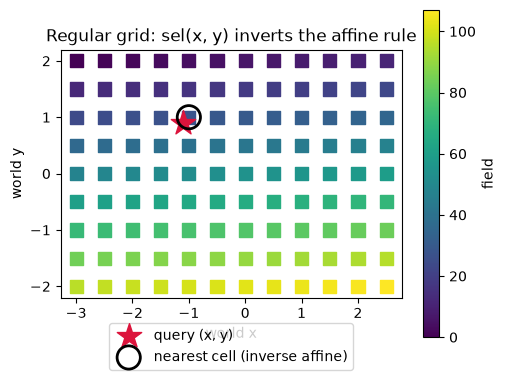

In [49]:
# a 12x9 world grid — 6 numbers (x0, y0, dx, dy + shape) place every cell; x/y aren't stored
tr = AffineGridTransform(x0=-3.0, y0=2.0, dx=0.5, dy=-0.5, nx=12, ny=9)
grid = xr.DataArray(np.arange(9 * 12).reshape(9, 12).astype(float),
                    dims=("yj", "xi"),
                    coords=Coordinates.from_xindex(CoordinateTransformIndex(tr)),
                    name="field")

# THE POINT: select by world (x, y); the index inverts the affine rule to find the cell
cell = grid.sel(x=xr.DataArray([-1.1], dims="q"),
                y=xr.DataArray([0.9], dims="q"), method="nearest").isel(q=0)

assert grid.x.dims == ("yj", "xi")                     # coords span both grid dims
assert (float(cell.x), float(cell.y)) == (-1.0, 1.0)   # inverse affine landed in the right cell
print("x / y generated by the rule, nothing stored:", type(grid.x.variable._data).__name__)

fig, ax = plt.subplots(figsize=(5.5, 5))
sc = ax.scatter(grid.x.values, grid.y.values, c=grid.values, cmap="viridis", s=90, marker="s")
fig.colorbar(sc, ax=ax, label="field", shrink=0.85)
ax.scatter([-1.1], [0.9], marker="*", s=340, c="crimson", zorder=5, label="query (x, y)")
ax.scatter([float(cell.x)], [float(cell.y)], edgecolor="k", facecolor="none", s=280, lw=2,
           zorder=6, label="nearest cell (inverse affine)")
ax.set_aspect("equal"); ax.set_xlabel("world x"); ax.set_ylabel("world y")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.32))
ax.set_title("Regular grid: sel(x, y) inverts the affine rule")
plt.show()

### The built-in twin: affine rasters in the gallery

That's a working custom index in a handful of lines. On a regular grid it beats `NDPointIndex` cleanly: **no coordinate arrays are stored** (they come from 6 numbers) and **there's no tree to build or search** — selection is one subtract‑and‑divide per axis. That's the "exploit the structure" payoff: when you *know* the rule, the index barely has to work.

And — just as the ruler was a DIY `RangeIndex` — you rarely need to write this one yourself either. The *same* `CoordinateTransform` pattern powers production indexes for **affine rasters, rotated‑pole grids, and map projections**: see [`rasterix`](https://github.com/dcherian/rasterix)'s `RasterIndex` (a GDAL‑style affine geotransform) and more in the [Xarray Indexes Gallery](https://xarray-indexes.readthedocs.io/). You write your own only when the rule is one nobody's packaged yet — like the fisheye lens next.

## 🔍 Level 2 — a fisheye lens: a *nonlinear* rule

Our scenario: a fisheye camera photographs a flat checkerboard. The **image is distorted**, the **world is flat**, and we want to ask questions in *world* coordinates.

**The distortion model, up front.** We keep ordinary **Cartesian** world coordinates `(x, y)` — a lens doesn't change that. What it changes is *radial*: a point's **direction** from the image centre is preserved, only its **distance** is stretched, by a factor that depends on the radius `r = √(x² + y²)`. Our model (the "division" model):

$$(x_\text{world},\, y_\text{world}) = (x,\, y)\;\cdot\;\frac{1}{1 - k\,r^2}, \qquad r = \sqrt{x^2 + y^2}$$

Straight lines bow outward — **barrel** distortion. Because the factor depends on `r`, each world coordinate depends on **both** pixel axes; that "radial" coupling is exactly why two independent 1-D coordinates can't describe it, and we need a 2-D transform.

Let's start with the data:

In [28]:
SQUARES = 1.5   # checkerboard squares per world unit (shared by the checker + the world-grid overlay)


def checker(x, y, squares=SQUARES):
    return ((np.floor(x * squares) + np.floor(y * squares)) % 2).astype(float)

nx = ny = 1024
k = 0.35                                                # lens distortion strength

# each sensor pixel looks out at a world point through the lens (radial model)
y_pixel, x_pixel = np.meshgrid(np.arange(ny), np.arange(nx), indexing="ij")
x_norm = (x_pixel - (nx - 1) / 2) / ((nx - 1) / 2)     # centered, normalized pixel coords
y_norm = (y_pixel - (ny - 1) / 2) / ((ny - 1) / 2)
factor = 1 / (1 - k * np.hypot(x_norm, y_norm) ** 2)   # fisheye: the periphery expands (barrel)
x_world, y_world = x_norm * factor, y_norm * factor    # the world position each pixel sees

photo = checker(x_world, y_world)                       # a flat checkerboard, seen through the lens
photo_da = xr.DataArray(photo, dims=("y_pixel", "x_pixel"),
                        coords={"x_pixel": np.arange(nx), "y_pixel": np.arange(ny)},
                        name="brightness")
photo_da                                                # our data: a plain, pixel-indexed image

<xarray.DataArray 'brightness' (y_pixel: 1024, x_pixel: 1024)> Size: 8MB
array([[0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.]], shape=(1024, 1024))
Coordinates:
  * y_pixel  (y_pixel) int64 8kB 0 1 2 3 4 5 6 ... 1018 1019 1020 1021 1022 1023
  * x_pixel  (x_pixel) int64 8kB 0 1 2 3 4 5 6 ... 1018 1019 1020 1021 1022 1023

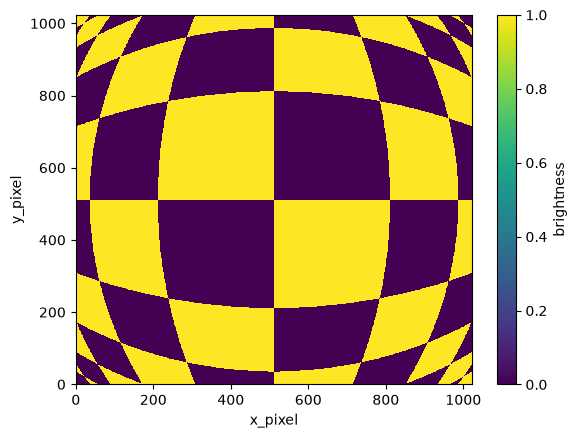

In [29]:
photo_da.plot()

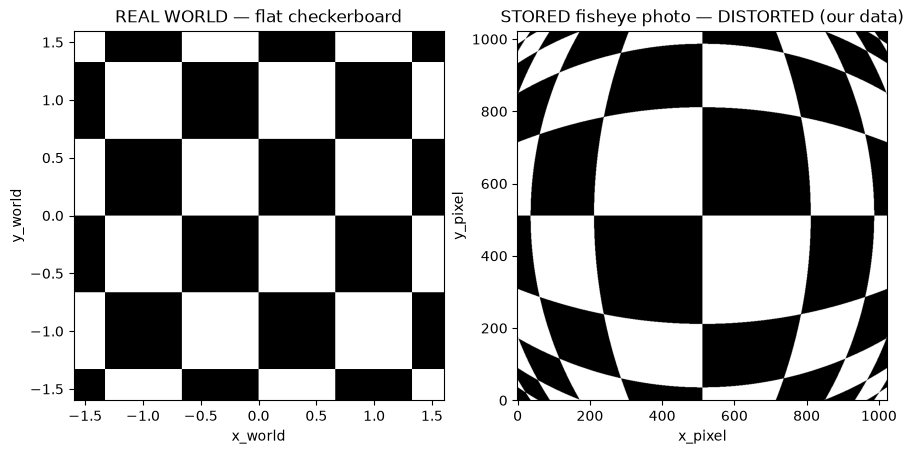

In [30]:
# the flat world (the scene) vs the distorted photo (our data)
world_grid = np.linspace(-1.6, 1.6, 400)
flat = checker(*np.meshgrid(world_grid, world_grid))

fig, (ax_world, ax_photo) = plt.subplots(1, 2, figsize=(10.5, 5.2))
ax_world.imshow(flat, cmap="gray", origin="lower", extent=[-1.6, 1.6, -1.6, 1.6])
ax_world.set_title("REAL WORLD — flat checkerboard")
ax_world.set_xlabel("x_world"); ax_world.set_ylabel("y_world")
ax_photo.imshow(photo, cmap="gray", origin="lower")
ax_photo.set_title("STORED fisheye photo — DISTORTED (our data)")
ax_photo.set_xlabel("x_pixel"); ax_photo.set_ylabel("y_pixel")
plt.show()

### Attempt 1 (the intuitive thing): store the undistorted coordinates

The obvious move: attach `x_world` and `y_world` as **coordinate variables** and select on them. Let's try it:

In [31]:
# Attempt 1: store the world coords as 2-D coordinate variables (on the pixel dims)
distorted = xr.DataArray(photo, dims=("y_pixel", "x_pixel"),
                         coords={"x_world": (("y_pixel", "x_pixel"), x_world),
                                 "y_world": (("y_pixel", "x_pixel"), y_world)},
                         name="brightness")
distorted

<xarray.DataArray 'brightness' (y_pixel: 1024, x_pixel: 1024)> Size: 8MB
array([[0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.]], shape=(1024, 1024))
Coordinates:
    x_world  (y_pixel, x_pixel) float64 8MB -3.333 -3.312 -3.29 ... 3.312 3.333
    y_world  (y_pixel, x_pixel) float64 8MB -3.333 -3.318 -3.303 ... 3.318 3.333
Dimensions without coordinates: y_pixel, x_pixel

In [32]:
# select by world position -- the natural thing to try
try:
    distorted.sel(x_world=0.3, y_world=0.15, method="nearest")
except Exception as e:
    print("💥", type(e).__name__, ":", str(e))

💥 ValueError : Could not automatically create PandasIndex for coord 'x_world' with 2 dimensions. Please explicitly set the index using `set_xindex`.


**It breaks.** A coordinate *variable* is just labels — to `.sel` on it you need an **index**, and xarray can't auto-build the default `PandasIndex` here because these coordinates are **2‑D** (`PandasIndex` is 1‑D only). Storing the array bought us nothing for selection.

### Attempt 2: put an `NDPointIndex` on the stored coordinates

We *can* index 2‑D coordinates — give them a KD‑tree:

In [33]:
point_indexed = distorted.set_xindex(["x_world", "y_world"], NDPointIndex)
point_indexed.sel(x_world=xr.DataArray([0.3, -0.5], dims="q"),
                  y_world=xr.DataArray([0.15, 0.4], dims="q"), method="nearest")

<xarray.DataArray 'brightness' (q: 2)> Size: 16B
array([0., 1.])
Coordinates:
    x_world  (q) float64 16B 0.2992 -0.4991
    y_world  (q) float64 16B 0.1491 0.3999
Dimensions without coordinates: q

### The better fix: the coordinates follow a *rule*

Those `x_world`/`y_world` arrays didn't fall from the sky — we *computed* them from the lens rule stated at the top. So encode the **rule**, not its samples. That radial rule has a closed-form inverse:

$$\text{world } r = \frac{\text{pixel } r}{1 - k\,(\text{pixel } r)^2} \qquad\Longleftrightarrow\qquad \text{pixel } r = \frac{-1 + \sqrt{1 + 4k\,(\text{world } r)^2}}{2k\,(\text{world } r)}$$

so `forward` applies the lens (pixel → world) and `reverse` undoes it (world → pixel):

In [34]:
class FisheyeTransform(CoordinateTransform):
    """Radial fisheye lens: pixel (x_pixel, y_pixel) <-> world (x_world, y_world).
       world_r = pixel_r / (1 - k * pixel_r**2)  — barrel, with a closed-form inverse."""

    def __init__(self, nx, ny, k):
        super().__init__(("x_world", "y_world"), {"y_pixel": ny, "x_pixel": nx})
        self.nx, self.ny, self.k = nx, ny, k

    def _normalize(self, x_pixel, y_pixel):          # pixel indices -> centered, normalized
        return ((np.asarray(x_pixel) - (self.nx - 1) / 2) / ((self.nx - 1) / 2),
                (np.asarray(y_pixel) - (self.ny - 1) / 2) / ((self.ny - 1) / 2))

    def forward(self, dim_positions):                # pixel -> world (undistort)
        x_norm, y_norm = self._normalize(dim_positions["x_pixel"], dim_positions["y_pixel"])
        factor = 1 / (1 - self.k * np.hypot(x_norm, y_norm) ** 2)
        return {"x_world": x_norm * factor, "y_world": y_norm * factor}

    def reverse(self, coord_labels):                 # world -> pixel (distort, closed form)
        x_world = np.asarray(coord_labels["x_world"])
        y_world = np.asarray(coord_labels["y_world"])
        world_r = np.hypot(x_world, y_world)
        with np.errstate(divide="ignore", invalid="ignore"):
            pixel_r = (-1 + np.sqrt(1 + 4 * self.k * world_r ** 2)) / (2 * self.k * world_r)
            scale = np.where(world_r > 0, pixel_r / world_r, 1.0)
        return {"x_pixel": (x_world * scale) * ((self.nx - 1) / 2) + (self.nx - 1) / 2,
                "y_pixel": (y_world * scale) * ((self.ny - 1) / 2) + (self.ny - 1) / 2}

    def equals(self, other, exclude=None):
        return (isinstance(other, FisheyeTransform)
                and (self.nx, self.ny, self.k) == (other.nx, other.ny, other.k))


# one lens instance drives both the index AND the manual reverse() calls in later cells
lens = FisheyeTransform(nx, ny, k)

# the world coords are GENERATED from the rule — note they are lazy in the repr below
fish = xr.DataArray(photo, dims=("y_pixel", "x_pixel"),
                    coords=Coordinates.from_xindex(CoordinateTransformIndex(lens)),
                    name="brightness")
fish

<xarray.DataArray 'brightness' (y_pixel: 1024, x_pixel: 1024)> Size: 8MB
array([[0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.]], shape=(1024, 1024))
Coordinates:
  * x_world  (y_pixel, x_pixel) float64 8MB -3.333 -3.312 -3.29 ... 3.312 3.333
  * y_world  (y_pixel, x_pixel) float64 8MB -3.333 -3.318 -3.303 ... 3.318 3.333
Dimensions without coordinates: y_pixel, x_pixel
Indexes:
  ┌ x_world  CoordinateTransformIndex
  └ y_world

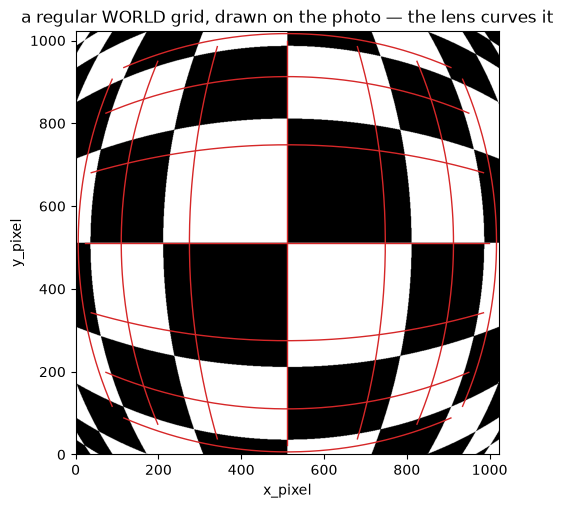

In [35]:
# what the lens does, as a grid: a regular WORLD grid drawn on the photo bends into curves
t = np.linspace(-1.4, 1.4, 200)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(photo, cmap="gray", origin="lower")
for c in np.arange(-1.5, 1.6, 0.5):
    v = lens.reverse({"x_world": np.full_like(t, c), "y_world": t})
    h = lens.reverse({"x_world": t, "y_world": np.full_like(t, c)})
    ax.plot(v["x_pixel"], v["y_pixel"], c="tab:red", lw=1)
    ax.plot(h["x_pixel"], h["y_pixel"], c="tab:red", lw=1)
ax.set_xlim(0, nx - 1); ax.set_ylim(0, ny - 1)
ax.set_xlabel("x_pixel"); ax.set_ylabel("y_pixel")
ax.set_title("a regular WORLD grid, drawn on the photo — the lens curves it")
plt.show()

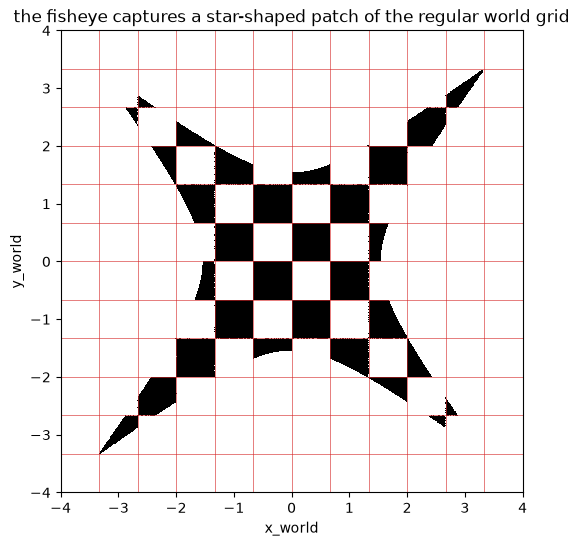

In [36]:
# a regular WORLD grid (straight lines) with the captured data on top:
# the "star" is just the patch of the flat world the fisheye actually saw
fig, ax = plt.subplots(figsize=(6, 6))
for c in np.arange(-4, 4.01, 1 / SQUARES):      # spacing = one checkerboard square in world
    ax.axhline(c, color="tab:red", lw=0.6, alpha=0.7)
    ax.axvline(c, color="tab:red", lw=0.6, alpha=0.7)
fish.plot(x="x_world", y="y_world", ax=ax, cmap="gray", add_colorbar=False)
ax.set_xlim(-4, 4); ax.set_ylim(-4, 4); ax.set_aspect("equal")
ax.set_title("the fisheye captures a star-shaped patch of the regular world grid")
plt.show()

### The payoff: selecting in *world* coordinates

Now that `fish` is indexed by **world** `(x_world, y_world)`, questions about the *scene* are one-liners — even though the data is a distorted photo. On the raw pixels you'd invert the lens by hand for every query, and a straight world line is a **curved path** across the sensor.

- **A point** — is world `(0.3, 0.2)` black or white? (`0` = black, `1` = white)
- **A line** — read the brightness along a straight world line: `.sel` gives the true, regular square wave, while a naive pixel row (`.isel`) gives a *warped* one.

In [37]:
# is the world point (0.3, 0.2) black or white?  — the result carries the world coords it resolved to
fish.sel(x_world=xr.DataArray(0.3), y_world=xr.DataArray(0.2), method="nearest")

<xarray.DataArray 'brightness' ()> Size: 8B
array(0.)
Coordinates:
    x_world  float64 8B 0.301
    y_world  float64 8B 0.201

sampled 200 points along the world line in a single call


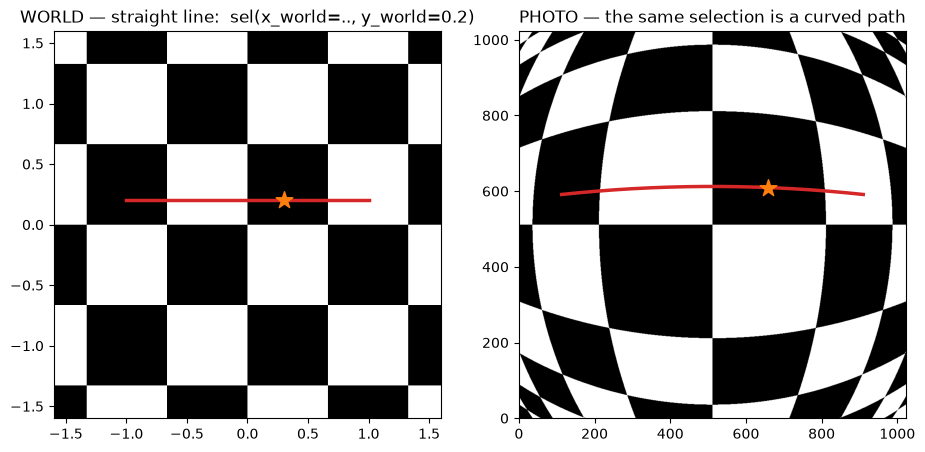

In [42]:
# THE POINT: a straight line in the WORLD (y_world = 0.2), sampled in one .sel call
line_x = np.linspace(-1.0, 1.0, 200)
line = fish.sel(x_world=xr.DataArray(line_x, dims="s"),
                y_world=xr.DataArray(np.full_like(line_x, 0.2), dims="s"), method="nearest")
print("sampled", line.sizes["s"], "points along the world line in a single call")

# --- plotting: that same straight world line traces a CURVE across the pixels ---
# (by hand, via the lens' reverse() — exactly the work .sel just did for us)
path = lens.reverse({"x_world": line_x, "y_world": np.full_like(line_x, 0.2)})
point = lens.reverse({"x_world": np.array([0.3]), "y_world": np.array([0.2])})
flat = checker(*np.meshgrid(np.linspace(-1.6, 1.6, 400), np.linspace(-1.6, 1.6, 400)))

fig, (ax_world, ax_photo) = plt.subplots(1, 2, figsize=(11, 5.2))
ax_world.imshow(flat, cmap="gray", origin="lower", extent=[-1.6, 1.6, -1.6, 1.6])
ax_world.plot(line_x, np.full_like(line_x, 0.2), c="tab:red", lw=2.5)
ax_world.scatter([0.3], [0.2], c="tab:orange", s=160, marker="*", zorder=5)
ax_world.set_title("WORLD — straight line:  sel(x_world=.., y_world=0.2)")
ax_photo.imshow(photo, cmap="gray", origin="lower")
ax_photo.plot(path["x_pixel"], path["y_pixel"], c="tab:red", lw=2.5)
ax_photo.scatter(point["x_pixel"], point["y_pixel"], c="tab:orange", s=160, marker="*", zorder=5)
ax_photo.set_title("PHOTO — the same selection is a curved path")
plt.show()

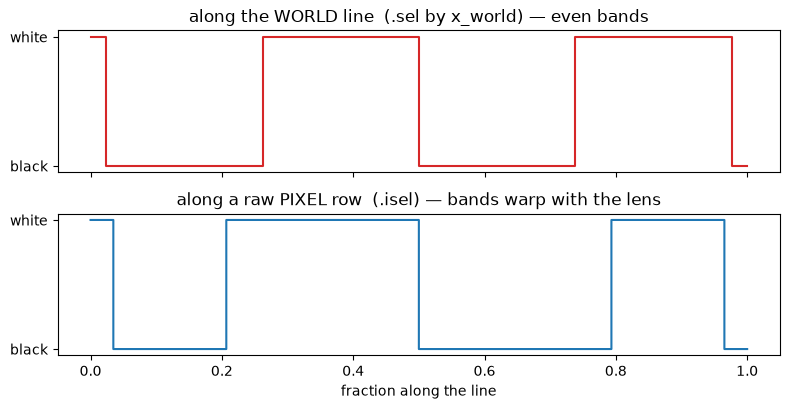

In [39]:
# read the brightness ALONG the line: world selection is a clean square wave; a raw pixel row is warped
world_line = fish.sel(x_world=xr.DataArray(np.linspace(-1.4, 1.4, 400), dims="s"),
                      y_world=xr.DataArray(np.zeros(400), dims="s"), method="nearest")
pixel_row = fish.isel(y_pixel=ny // 2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 4.2), sharex=True)
ax1.step(np.linspace(0, 1, world_line.sizes["s"]), world_line.values, where="mid", c="tab:red")
ax1.set_title("along the WORLD line  (.sel by x_world) — even bands")
ax2.step(np.linspace(0, 1, pixel_row.sizes["x_pixel"]), pixel_row.values, where="mid", c="tab:blue")
ax2.set_title("along a raw PIXEL row  (.isel) — bands warp with the lens")
for ax in (ax1, ax2):
    ax.set_yticks([0, 1]); ax.set_yticklabels(["black", "white"])
ax2.set_xlabel("fraction along the line")
fig.tight_layout(); plt.show()

### Three ways, one lesson

| Approach | `.sel` by world coords? | Cost |
|---|---|---|
| store `(x_world, y_world)` as coord vars, *no index* | ❌ **breaks** (2‑D coord → no `PandasIndex`) | — |
| stored coords **+ `NDPointIndex`** | ✅ works (nearest *sampled* pixel) | stores both arrays (~256 MB for 4000²) + builds a tree |
| **`FisheyeTransform`** (the rule) | ✅ works (exact analytic inverse) | ~3 numbers, coords lazy, no tree |

So *"why not just add a second coordinate variable?"* — because a coordinate variable alone can't be selected on (you need an index), and a 2‑D one can't take the default index at all. Once you're attaching a custom index either way, encoding the **rule** beats storing its samples: it's **exact** (not nearest-over-samples), **lazy** (nothing stored), resolution-independent, and aligns by comparing a few parameters.

**The honest boundary:** if the mapping is *only* known as sampled arrays — a measured calibration map, or a model's curvilinear grid with no formula — then storing the coordinates **+ `NDPointIndex` is exactly right** (that's the curvilinear-grid case). The transform wins when you have an analytic **rule**, and a lens is the poster child.

> 📝 **Stretch exercise:** swap the division model for [Brown–Conrady](https://en.wikipedia.org/wiki/Distortion_(optics)) radial distortion $r_d = r_u(1 + k_1 r_u^2 + k_2 r_u^4)$. `forward` is easy; `reverse` has no closed form — solve it with a few Newton iterations inside `reverse`.

### Does the index even need coordinate *variables* — and are they materialized?

Look back at `fish`: `x_world` and `y_world` appear as coordinates, but they're **lazy** — a `CoordinateTransformIndexingAdapter`, conjured from the rule on demand and never stored. So *"do we absolutely need the `x_world`/`y_world` arrays?"* → **no.** We need the *rule*; the coordinates are generated from it.

**Crucially, `Coordinates.from_xindex(index)` does not instantiate anything.** It asks the index for its coordinate variables via `create_variables()`, and a `CoordinateTransform` hands them back wrapped in a lazy `CoordinateTransformIndexingAdapter` — no arrays allocated. The transform's `forward` runs only when you actually *touch* values (`.values`, plotting, arithmetic), and only for the slice you index. A 4000² fisheye coordinate therefore costs ~nothing until used, and selecting a handful of points computes only those points.

But the index does need to **expose** those coordinates *by name*: `.sel(x_world=…)` finds the index registered for the coordinate `x_world` and calls its `sel`. You can't select by a label that isn't a coordinate — so the coordinate must **exist**, it just needn't be **materialized**. (Plotting is the same: `fish.plot(x="x_world", y="y_world")` reads those values, realizing them through `forward` — the index's coordinate *generation*, not its `sel`.)

This is exactly how the built-in [`RangeIndex`](https://docs.xarray.dev/en/stable/generated/xarray.indexes.RangeIndex.html) works: a 1‑D coordinate generated lazily (the *same* adapter) from `start`/`stop`/`step`, with no backing array. Our fisheye is the 2‑D, nonlinear cousin: **the data is indexed by pixels, but selectable in world space**, the world coordinates existing only as a lazy view.

## Summary — which index, when?

A coordinate stores **what the labels are**; an index is a **precomputed lookup structure** for them — and, for a custom index, one that encodes the *rule or structure* of the coordinate system. The through-line: *the richer the structure in your data, the more a well-matched index can exploit.*

| Your situation | Use | Why |
|---|---|---|
| 1‑D coordinate | built-in **`PandasIndex`** (automatic) | ergonomics (`nearest` / `slice`) + alignment; hash-table + binary-search lookups |
| data lying on a 1‑D shape (a curve) | still **`PandasIndex`** on the parameter | e.g. select circle points by `angle` — the query reduces to 1‑D |
| **regular 1‑D** axis (even one too big to store) | built-in **`RangeIndex`** | `start`/`stop`/`step` → labels generated lazily; scales to billions of points |
| genuinely 2‑D scattered points / curvilinear grid | **`NDPointIndex`** (KD‑tree) | `.sel` on `(x, y)` nearest + alignment a manual KD‑tree can't give |
| coordinates from a **rule** (regular / affine / rotated grid) | **`CoordinateTransform`** (write your own) | lazy coords, arithmetic inverse, **no tree, nothing stored** |
| anything else | a full custom **`Index`** | complete control over `sel` / `align` / `concat` |

**The deciding question isn't "can I compute the positions?"** — you almost always can, by hand. It's **"do I want xarray to *know* the structure, so it flows through `.sel`, alignment, `concat` / `merge`, and survives operations?"**

*See also: the **[Xarray Indexes Gallery](https://xarray-indexes.readthedocs.io/)** ([source](https://github.com/xarray-contrib/xarray-indexes)) · [how to create a custom index](https://docs.xarray.dev/en/stable/internals/how-to-create-custom-index.html) · [indexing user guide](https://docs.xarray.dev/en/stable/user-guide/indexing.html).*